In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- Configuration ---
batch_size = 64
learning_rate = 0.001

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [120]:
# --- Data loading ---
transform = transforms.Compose([
    transforms.ToTensor(),                   # convert images to tensors
    #transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST normalization
])

transform1 = transforms.Compose([
    transforms.Resize((4, 4)),
    transforms.ToTensor(),                   # convert images to tensors
    #transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST normalization
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_dataset1 = datasets.MNIST(root='./data', train=True, transform=transform1, download=True)
test_dataset1 = datasets.MNIST(root='./data', train=False, transform=transform1, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
train_loader1 = DataLoader(train_dataset1, batch_size=batch_size, shuffle=True)
test_loader1 = DataLoader(test_dataset1, batch_size=1000, shuffle=False)

In [88]:
# As 4x4 image
scaled_train_dataset = []
labels = []
for data_point in tqdm(train_dataset):
    image = data_point[0][0]
    newimage = np.zeros((4, 4))
    for x in range(4):
        for y in range(4):
            newimage[x, y] = np.mean(np.asarray(image[x * 7:x * 7 + 7, y * 7:y * 7 +7]))
    scaled_train_dataset.append(torch.tensor(newimage))
    labels.append(data_point[1])

100%|██████████| 60000/60000 [00:33<00:00, 1770.77it/s]


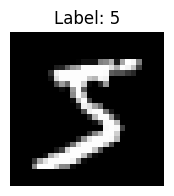

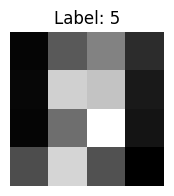

In [108]:
def visualize(datapoint):
    image, label = datapoint[0], datapoint[1]
    plt.figure(figsize=(2, 2))
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

visualize(train_dataset[0])
visualize(train_dataset1[0])

In [121]:
# --- Define CNN --- NORMAL
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        # fully connected layers
        #self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc1 = nn.Linear(64 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))     # 1st conv layer
        x = self.pool(F.relu(self.conv2(x)))  # 2nd conv + pooling
        x = self.dropout(x)
        #x = x.view(-1, 64 * 14 * 14)    # flatten
        x = x.view(-1, 64 * 2 * 2)    # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)               # output logits
        return x

model = SimpleCNN()

# --- Optimizer and loss ---
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()


In [122]:
# --- Training loop ---
for epoch in range(100):
    model.train()
    for batch_idx, (data, target) in tqdm(enumerate(train_loader1)):
        optimizer.zero_grad()
        output = model(data)
        #print(output.shape)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

938it [00:10, 87.17it/s]


Epoch 0: Loss = 0.6268


938it [00:11, 84.65it/s]


Epoch 1: Loss = 0.4764


938it [00:10, 86.06it/s]


...

Epoch 97: Loss = 0.1557


938it [00:11, 83.24it/s]


Epoch 98: Loss = 0.0180


938it [00:11, 84.75it/s]

Epoch 99: Loss = 0.1225


In [123]:
# --- Evaluation ---
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in tqdm(test_loader1):
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 10/10 [00:01<00:00,  8.41it/s]

Test Accuracy: 94.95%
